In [ ]:
import os
from random import randint, seed
import itertools
import numpy as np
import cv2

In [ ]:
class MaskGenerator():

    def __init__(self, height, width, channels=3, rand_seed=None, filepath=None):
        """Convenience functions for generating masks to be used for inpainting training
        
        Arguments:
            height {int} -- Mask height
            width {width} -- Mask width
        
        Keyword Arguments:
            channels {int} -- Channels to output (default: {3})
            rand_seed {[type]} -- Random seed (default: {None})
            filepath {[type]} -- Load masks from filepath. If None, generate masks with OpenCV (default: {None})
        """

        self.height = height
        self.width = width
        self.channels = channels
        self.filepath = filepath

        # If filepath supplied, load the list of masks within the directory
        self.mask_files = []
        if self.filepath:
            filenames = [f for f in os.listdir(self.filepath)]
            self.mask_files = [f for f in filenames if any(filetype in f.lower() for filetype in ['.jpeg', '.png', '.jpg'])]
            print(">> Found {} masks in {}".format(len(self.mask_files), self.filepath))        

        # Seed for reproducibility
        if rand_seed:
            seed(rand_seed)

    def _generate_mask(self):
        """Generates a random irregular mask with lines, circles and elipses"""

        img = np.zeros((self.height, self.width, self.channels), np.uint8)

        # Set size scale
        size = int((self.width + self.height) * 0.03)
        if self.width < 64 or self.height < 64:
            raise Exception("Width and Height of mask must be at least 64!")
        
        # Draw random lines
        for _ in range(randint(1, 20)):
            x1, x2 = randint(1, self.width), randint(1, self.width)
            y1, y2 = randint(1, self.height), randint(1, self.height)
            thickness = randint(3, size)
            cv2.line(img,(x1,y1),(x2,y2),(1,1,1),thickness)
            
        # Draw random circles
        for _ in range(randint(1, 20)):
            x1, y1 = randint(1, self.width), randint(1, self.height)
            radius = randint(3, size)
            cv2.circle(img,(x1,y1),radius,(1,1,1), -1)
            
        # Draw random ellipses
        for _ in range(randint(1, 20)):
            x1, y1 = randint(1, self.width), randint(1, self.height)
            s1, s2 = randint(1, self.width), randint(1, self.height)
            a1, a2, a3 = randint(3, 180), randint(3, 180), randint(3, 180)
            thickness = randint(3, size)
            cv2.ellipse(img, (x1,y1), (s1,s2), a1, a2, a3,(1,1,1), thickness)
        
        return 1-img

    def _load_mask(self, rotation=True, dilation=True, cropping=True):
        """Loads a mask from disk, and optionally augments it"""

        # Read image
        mask = cv2.imread(os.path.join(self.filepath, np.random.choice(self.mask_files, 1, replace=False)[0]))
        
        # Random rotation
        if rotation:
            rand = np.random.randint(-180, 180)
            M = cv2.getRotationMatrix2D((mask.shape[1]/2, mask.shape[0]/2), rand, 1.5)
            mask = cv2.warpAffine(mask, M, (mask.shape[1], mask.shape[0]))
            
        # Random dilation
        if dilation:
            rand = np.random.randint(5, 47)
            kernel = np.ones((rand, rand), np.uint8) 
            mask = cv2.erode(mask, kernel, iterations=1)
            
        # Random cropping
        if cropping:
            x = np.random.randint(0, mask.shape[1] - self.width)
            y = np.random.randint(0, mask.shape[0] - self.height)
            mask = mask[y:y+self.height, x:x+self.width]

        return (mask > 1).astype(np.uint8)

    def sample(self, random_seed=None):
        """Retrieve a random mask"""
        if random_seed:
            seed(random_seed)
        if self.filepath and len(self.mask_files) > 0:
            return self._load_mask()
        else:
            return self._generate_mask()


class ImageChunker(object): 
    
    def __init__(self, rows, cols, overlap):
        self.rows = rows
        self.cols = cols
        self.overlap = overlap
    
    def perform_chunking(self, img_size, chunk_size):
        """
        Given an image dimension img_size, return list of (start, stop) 
        tuples to perform chunking of chunk_size
        """
        chunks, i = [], 0
        while True:
            chunks.append((i*(chunk_size - self.overlap/2), i*(chunk_size - self.overlap/2)+chunk_size))
            i+=1
            if chunks[-1][1] > img_size:
                break
        n_count = len(chunks)        
        chunks[-1] = tuple(x - (n_count*chunk_size - img_size - (n_count-1)*self.overlap/2) for x in chunks[-1])
        chunks = [(int(x), int(y)) for x, y in chunks]
        return chunks
    
    def get_chunks(self, img, scale=1):
        """
        Get width and height lists of (start, stop) tuples for chunking of img.
        """
        x_chunks, y_chunks = [(0, self.rows)], [(0, self.cols)]        
        if img.shape[0] > self.rows:
            x_chunks = self.perform_chunking(img.shape[0], self.rows)
        else:
            x_chunks = [(0, img.shape[0])]
        if img.shape[1] > self.cols:
            y_chunks = self.perform_chunking(img.shape[1], self.cols)
        else:
            y_chunks = [(0, img.shape[1])]
        return x_chunks, y_chunks    
    
    def dimension_preprocess(self, img, padding=True):
        """
        In case of prediction on image of different size than 512x512,
        this function is used to add padding and chunk up the image into pieces
        of 512x512, which can then later be reconstructed into the original image
        using the dimension_postprocess() function.
        """
    
        # Assert single image input
        assert len(img.shape) == 3, "Image dimension expected to be (H, W, C)"
    
        # Check if we are adding padding for too small images
        if padding:
            
            # Check if height is too small
            if img.shape[0] < self.rows:
                padding = np.ones((self.rows - img.shape[0], img.shape[1], img.shape[2]))
                img = np.concatenate((img, padding), axis=0)
    
            # Check if width is too small
            if img.shape[1] < self.cols:
                padding = np.ones((img.shape[0], self.cols - img.shape[1], img.shape[2]))
                img = np.concatenate((img, padding), axis=1)
    
        # Get chunking of the image
        x_chunks, y_chunks = self.get_chunks(img)
    
        # Chunk up the image
        images = []
        for x in x_chunks:
            for y in y_chunks:
                images.append(
                    img[x[0]:x[1], y[0]:y[1], :]
                )
        images = np.array(images)        
        return images
    
    def dimension_postprocess(self, chunked_images, original_image, scale=1, padding=True):
        """
        In case of prediction on image of different size than 512x512,
        the dimension_preprocess  function is used to add padding and chunk 
        up the image into pieces of 512x512, and this function is used to 
        reconstruct these pieces into the original image.
        """
    
        # Assert input dimensions
        assert len(original_image.shape) == 3, "Image dimension expected to be (H, W, C)"
        assert len(chunked_images.shape) == 4, "Chunked images dimension expected to be (B, H, W, C)"
        
        # Check if we are adding padding for too small images
        if padding:
    
            # Check if height is too small
            if original_image.shape[0] < self.rows:
                new_images = []
                for img in chunked_images:
                    new_images.append(img[0:scale*original_image.shape[0], :, :])
                chunked_images = np.array(new_images)
    
            # Check if width is too small
            if original_image.shape[1] < self.cols:
                new_images = []
                for img in chunked_images:
                    new_images.append(img[:, 0:scale*original_image.shape[1], :])
                chunked_images = np.array(new_images)
            
        # Put reconstruction into this array
        new_shape = (
            original_image.shape[0]*scale,
            original_image.shape[1]*scale,
            original_image.shape[2]
        )
        reconstruction = np.zeros(new_shape)
            
        # Get the chunks for this image    
        x_chunks, y_chunks = self.get_chunks(original_image)
        
        i = 0
        s = scale
        for x in x_chunks:
            for y in y_chunks:
                
                prior_fill = reconstruction != 0
                chunk = np.zeros(new_shape)
                chunk[x[0]*s:x[1]*s, y[0]*s:y[1]*s, :] += chunked_images[i]
                chunk_fill = chunk != 0
                
                reconstruction += chunk
                reconstruction[prior_fill & chunk_fill] = reconstruction[prior_fill & chunk_fill] / 2
    
                i += 1
        
        return reconstruction

**Mask Generation **

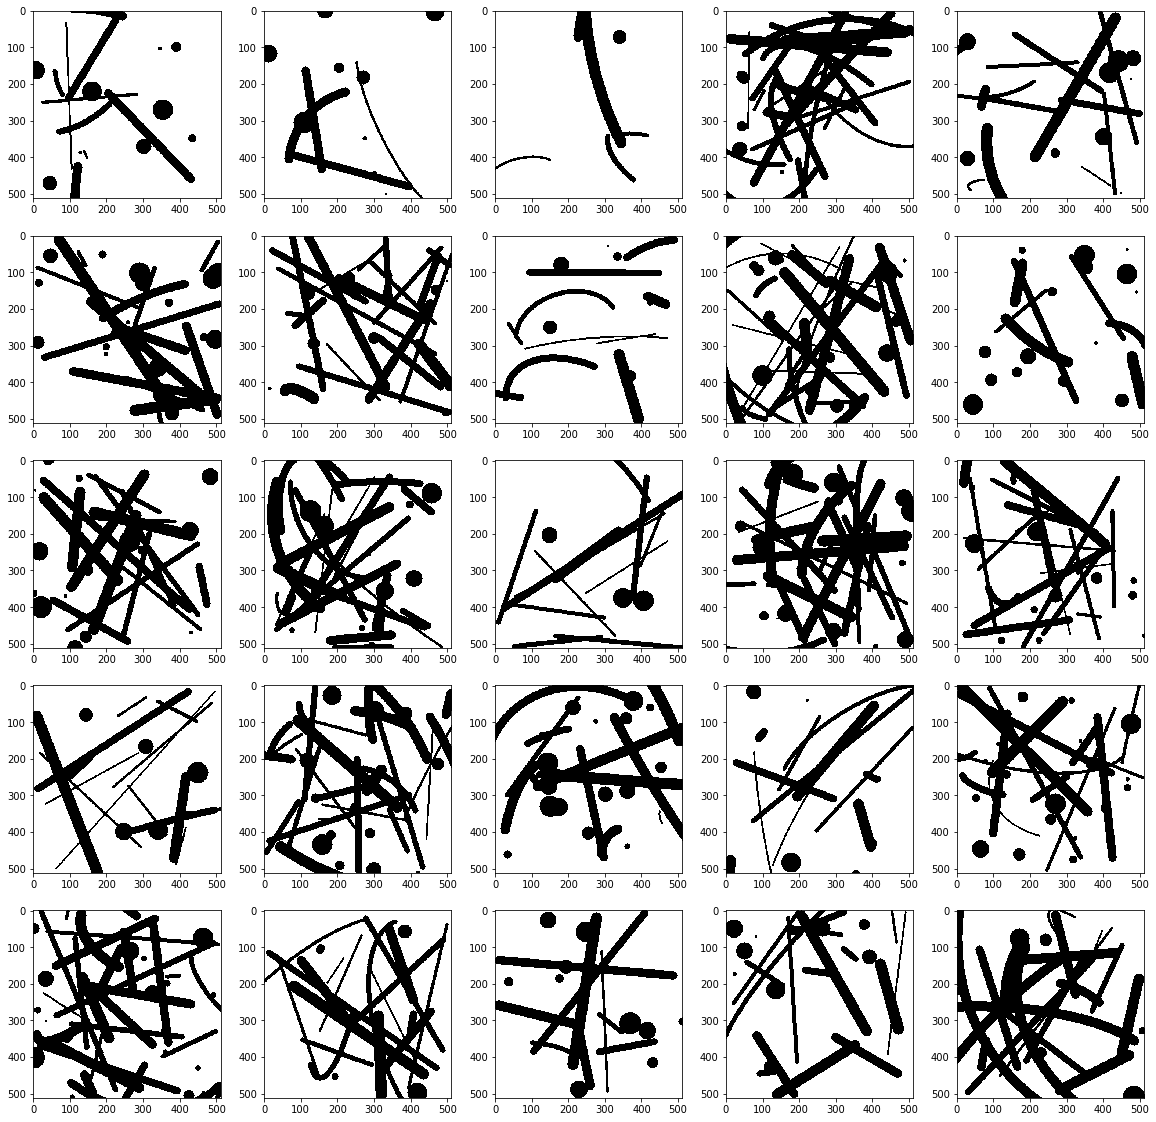

In [ ]:
import os
import itertools
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline

mask_generator = MaskGenerator(512, 512, 3, rand_seed=42)

# Plot the results
_, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = list(itertools.chain.from_iterable(axes))

for i in range(len(axes)):
    
    # Generate image
    img = mask_generator.sample()
    
    # Plot image on axis
    axes[i].imshow(img*255)

In [ ]:
!wget http://www.vision.caltech.edu/visipedia-data/CUB-200/images.tgz

--2019-05-03 05:22:35--  http://www.vision.caltech.edu/visipedia-data/CUB-200/images.tgz
Resolving www.vision.caltech.edu (www.vision.caltech.edu)... 34.208.54.77
Connecting to www.vision.caltech.edu (www.vision.caltech.edu)|34.208.54.77|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 679421896 (648M) [application/x-tar]
Saving to: ‘images.tgz’

images.tgz          100%[===================>] 647.95M  9.05MB/s    in 1m 42s  

2019-05-03 05:24:17 (6.38 MB/s) - ‘images.tgz’ saved [679421896/679421896]



In [ ]:
!gunzip images.tgz

In [ ]:
!tar -xvf images.tar

In [ ]:
!rm -rf bad

In [ ]:
import os
from copy import deepcopy
import cv2
import numpy as np
from skimage import transform
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
resolution = (256,256)
imgs_A = []
imgs_B = []
os.makedirs("bad")
for root, dirs, files in os.walk("./images/", topdown=False):
   for name in files:
      path_file = os.path.join(root, name)
      
      print(path_file)
      img = cv2.imread(path_file)
      if img is not None:
          #img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
          shape = img.shape
          #print(f"Shape of image is: {shape}")

          # Instantiate mask generator
          mask_generator = MaskGenerator(shape[0], shape[1], 3, rand_seed=42)

          # Load mask
          mask = mask_generator.sample()
          print(os.path.abspath(path_file))
          # Image + mask
          masked_img = deepcopy(img)
          masked_img[mask==0] = 255
          #to_file = 
          #print(to_file)
          #plt.imshow(masked_img)
          cv2.imwrite("bad/"+str(name),masked_img)

FileExistsError: ignored

In [ ]:
from __future__ import print_function, division
import numpy as np 
import pandas as pd 
import scipy
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Input, Dense, Reshape, Flatten, Dropout, Concatenate
from keras.layers import BatchNormalization, Activation, ZeroPadding2D
from keras.layers.advanced_activations import LeakyReLU
from keras.layers.convolutional import UpSampling2D, Conv2D
from keras.models import Sequential, Model
from keras.optimizers import Adam
import datetime
import sys
import os
import cv2
from skimage import transform
from imageio import imread

In [ ]:

resolution = (256,256)

# Input shape
img_rows = 256
img_cols = 256
channels = 3
img_shape = (img_rows, img_cols, channels)

# Size of Patch for PatchGAN
patch = int(img_rows / 2**2)
disc_patch = (patch, patch, 1)

# Number of filters for G and D
filters_gen = 64

#Optimizer for the GAN.
optimizer = Adam(0.0002, 0.5)


   

In [ ]:
def new_generator():
    layer0 = Input(shape=img_shape,name="input")
    layer1 = Conv2D(filters_gen, kernel_size=4,strides = 2,activation = LeakyReLU(alpha=0.2),padding='same')(layer0)
    bd = BatchNormalization(momentum=0.8)(layer1)
    layer2 = Conv2D(filters_gen*2, kernel_size=4,strides = 2,activation = LeakyReLU(alpha=0.2),padding='same')(bd)
    bd = BatchNormalization(momentum=0.8)(layer2)
    layer3 = Conv2D(filters_gen*4, kernel_size=4,strides = 2,activation = LeakyReLU(alpha=0.2),padding='same')(bd)
    bd = BatchNormalization(momentum=0.8)(layer3)
    layer4 = Conv2D(filters_gen*8, kernel_size=4,strides = 2,activation = LeakyReLU(alpha=0.2),padding='same')(bd)
    bd = BatchNormalization(momentum=0.8)(layer4)
    layer5 = Conv2D(filters_gen*8, kernel_size=4,strides = 2,activation = LeakyReLU(alpha=0.2),padding='same')(bd)
    bd = BatchNormalization(momentum=0.8)(layer5)
    layer6 = Conv2D(filters_gen*8, kernel_size=4,strides = 2,activation = LeakyReLU(alpha=0.2),padding='same')(bd)
    bd = BatchNormalization(momentum=0.8)(layer6)
    dropout = Dropout(0.10)(bd)
    layer7 = Conv2D(filters_gen*8, kernel_size=2,strides = 2,activation = LeakyReLU(alpha=0.2),padding='same')(dropout)
    bd = BatchNormalization(momentum=0.8)(layer7)
    def deconv2d(prev_layer, skip_input, filters):
        temp = UpSampling2D(size=2)(prev_layer)
        temp = Conv2D(filters, kernel_size=4, strides=1, padding='same', activation='relu')(temp)
        temp = BatchNormalization(momentum=0.6)(temp)
        temp = Concatenate()([temp, skip_input])
        return temp
    
    u_layer1 = deconv2d(bd, layer6, filters_gen*8)
    u_layer2 = deconv2d(u_layer1, layer5, filters_gen*8)
    u_layer3 = deconv2d(u_layer2, layer4, filters_gen*8)
    u_layer4 = deconv2d(u_layer3, layer3, filters_gen*4)
    dropout = Dropout(0.25)(u_layer4)
    u_layer5 = deconv2d(dropout, layer2, filters_gen*2)
    u_layer6 = deconv2d(u_layer5, layer1, filters_gen)
    u_layer7 = UpSampling2D(size=2)(u_layer6)
    u_layer0 = Conv2D(channels, kernel_size=4, strides=1, padding='same', activation='tanh')(u_layer7)
    return Model(layer0,u_layer0,name="Generator")


def new_discriminator():
    def d_layer(prev_layer, filters):
        print(filters)
        temp = Conv2D(filters, kernel_size=4, strides=2, padding='same')(prev_layer)
        temp = LeakyReLU(alpha=0.2)(temp)
        return temp
    
    layer0_A = Input(shape=img_shape)
    layer0_B = Input(shape=img_shape)
    combined_input = Concatenate(axis=-1)([layer0_A, layer0_B])
    layer1 = d_layer(combined_input, filters_gen)
    layer2 = d_layer(layer1, filters_gen*2)
    #layer3 = d_layer(layer2, filters_gen*4)
    #layer4 = d_layer(layer3, filters_gen*4)
    dropout = Dropout(0.25)(layer2)
    layer5 = Conv2D(1, kernel_size=4, strides=1, padding='same')(dropout)
    return Model([layer0_A, layer0_B], layer5,name="Discriminator")

heaven = new_discriminator()
heaven.summary()

64
128
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_19 (InputLayer)           (None, 256, 256, 3)  0                                            
__________________________________________________________________________________________________
input_20 (InputLayer)           (None, 256, 256, 3)  0                                            
__________________________________________________________________________________________________
concatenate_25 (Concatenate)    (None, 256, 256, 6)  0           input_19[0][0]                   
                                                                 input_20[0][0]                   
__________________________________________________________________________________________________
conv2d_61 (Conv2D)              (None, 128, 128, 64) 6208        concatenate_25[0][0]             
___

In [ ]:
d = new_discriminator()
d.compile(loss='mse',
            optimizer=optimizer,
            metrics=['accuracy'])


g = new_generator()

input_image_A = Input(shape = img_shape)
input_image_B = Input(shape = img_shape)

fake_image_B = g(input_image_B)
validity = d([fake_image_B,input_image_B])


d.trainable = False

gan = Model(inputs=[input_image_A,input_image_B],
            outputs = [validity,fake_image_B],name="GAN")

gan.compile(loss=['mse', 'mae'],
            loss_weights=[1, 100],
            optimizer=optimizer)
gan.summary()

64
128
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_24 (InputLayer)           (None, 256, 256, 3)  0                                            
__________________________________________________________________________________________________
Generator (Model)               (None, 256, 256, 3)  38697859    input_24[0][0]                   
__________________________________________________________________________________________________
Discriminator (Model)           (None, 64, 64, 1)    139457      Generator[1][0]                  
                                                                 input_24[0][0]                   
Total params: 38,837,316
Trainable params: 38,688,899
Non-trainable params: 148,417
__________________________________________________________________________________________________


In [ ]:
import csv
def make_index():
   write_main = open("index.csv",'w',newline="")
   writer = csv.writer(write_main)  
   for root, dirs, files in os.walk("./bad/", topdown=False):
         for name in files:
             print(name)
             writer.writerow([str(name)])
make_index()
             
    

Louisiana_Waterthrush_0027_2598269893.jpg
Eared_Grebe_0003_2411772459.jpg
Black_throated_Sparrow_0028_2846732474.jpg
Lazuli_Bunting_0019_2785250577.jpg
Gray_Kingbird_0012_179376918.jpg
Forsters_Tern_0004_294035839.jpg
Green_Kingfisher_0023_1975074259.jpg
Forsters_Tern_0001_2785441587.jpg
Pelagic_Cormorant_0001_426002425.jpg
Prairie_Warbler_0006_287222067.jpg
Orchard_Oriole_0014_2503615614.jpg
Chipping_Sparrow_0017_2747497035.jpg
Cape_Glossy_Starling_0021_2183151845.jpg
Horned_Puffin_0023_1320749917.jpg
Eastern_Towhee_0031_100173680.jpg
Loggerhead_Shrike_0029_2047999766.jpg
Cliff_Swallow_0001_1199523234.jpg
Brandt_Cormorant_0009_426236586.jpg
White_breasted_Kingfisher_0036_265120622.jpg
Florida_Jay_0006_2847477101.jpg
Cerulean_Warbler_0010_162160468.jpg
Red_headed_Woodpecker_0016_410463447.jpg
Bronzed_Cowbird_0014_2256262769.jpg
Grasshopper_Sparrow_0032_523704409.jpg
Belted_Kingfisher_0017_2281805508.jpg
Shiny_Cowbird_0025_1806109198.jpg
Geococcyx_0014_170828754.jpg
White_Pelican_0020_x

In [ ]:
import csv

def load_images(batch_size,i):
    imgs_A =[]
    imgs_B =[]
    with open("index.csv") as myfile:
       reader=csv.reader(myfile)
       head = [row[0] for idx, row in enumerate(reader) if idx in range(batch_size*i,(batch_size*i)+batch_size)]
    for i in head:
        
        for root, dirs, files in os.walk("./bad/", topdown=False):
             for name in files:             
                 #print(name)
                 if(name == i.strip()):
                      
                      path_file = os.path.join(root, name)
                      bad_file = imread(path_file)
                      #bad_file = cv2.cvtColor(bad_file, cv2.COLOR_BGR2RGB)
                      imgs_A.append(transform.resize(bad_file,resolution))
                      
                
      
        for root, dirs, files in os.walk("./images/", topdown=False):
             for name in files:             
                 #print(name)
                 if(name == i.strip()):
                      
                      path_file = os.path.join(root, name)
                      good_file = imread(path_file)
                      #good_file = cv2.cvtColor(good_file, cv2.COLOR_BGR2RGB)
                      imgs_B.append(transform.resize(good_file,resolution))
                      
    imgs_A = np.array(imgs_A)
    imgs_B = np.array(imgs_B)
    return imgs_B, imgs_A
    
   
                    
               
    
def plot_img():
    truth,labelled = load_images(1,1)
    
    predict = g.predict(labelled)
    plt.imshow(labelled[0])
    plt.show()
    plt.imshow(predict[0])
    plt.show()
    plt.imshow(truth[0])
    plt.show()


def train(epochs,batch_size):
    valid_scores = np.ones((batch_size,disc_patch[0],disc_patch[1],disc_patch[2]))
    fake_scores = np.zeros((batch_size,disc_patch[0],disc_patch[1],disc_patch[2]))
    for j in range(epochs):
        print("Epoch -",j+1)
        start = datetime.datetime.now()
        for i in range(0,40):# begin
            images_A,images_B = load_images(batch_size,i)
            
            fake_images = g.predict(images_B)

            #Discriminator losses
            d_loss_real = d.train_on_batch([images_A,images_B],valid_scores)
            d_loss_fake = d.train_on_batch([fake_images,images_B],fake_scores)
            avg_d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
            #GAN losses
            gan_loss = gan.train_on_batch([images_A,images_B],[valid_scores,images_A])
# end
        print("Discriminator Loss = ",avg_d_loss[0], "Accuracy =",avg_d_loss[1]*100)
        print("GAN Loss = ",gan_loss[0])
        end = start_time = datetime.datetime.now()
        print("Time Elapsed",end-start,"\n")
        if(j%5==0):
            plot_img()

In [ ]:
import warnings
warnings.filterwarnings("ignore")
train(25,15)

In [ ]:
g.load_weights('D2Ngen1.h5')
d.load_weights('D2Ndisc1.h5')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


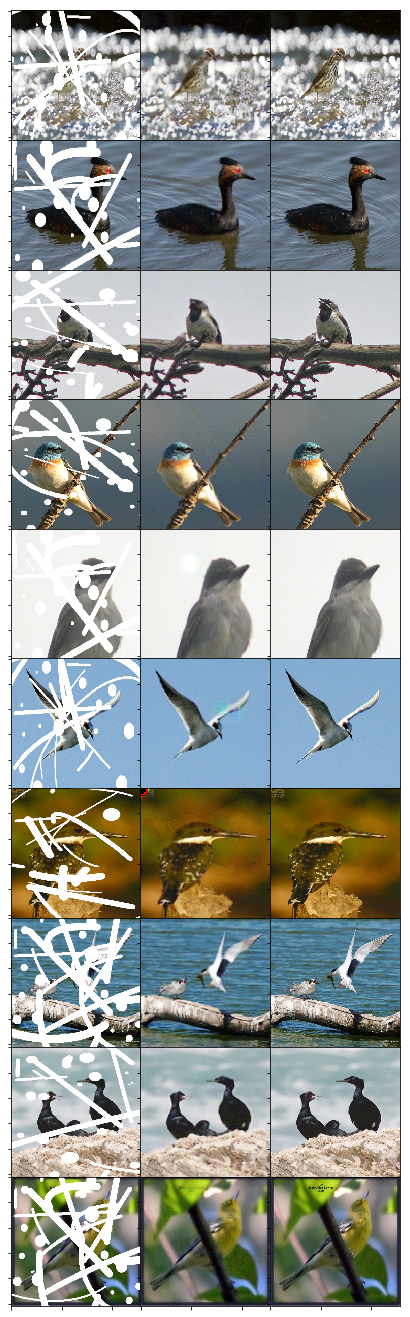

In [ ]:
truth,labelled = load_images(10,0)
predict = g.predict(labelled)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

nrow = 10
ncol = 3

fig = plt.figure(figsize=(8, 20)) 

gs = gridspec.GridSpec(nrow, ncol, width_ratios=[1, 1, 1],
         wspace=0.0, hspace=0.0, top=0.95, bottom=0.05, left=0.17, right=0.845) 

for i in range(10):    
        
        ax= plt.subplot(gs[i,0])
        ax.imshow(labelled[i])
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax= plt.subplot(gs[i,1])
        ax.imshow(predict[i])
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax= plt.subplot(gs[i,2])
        ax.imshow(truth[i])
        ax.set_xticklabels([])
        ax.set_yticklabels([])

#plt.tight_layout() # do not use this!!
plt.show()

# _, axes = plt.subplots(len(predict), 3, figsize=(20, 20),gridspec_kw = {'wspace':0})

# show = []
# for i in range(len(predict)): 
#         show.extend([labelled[i],predict[i],truth[i]])
#         axes[i,0].imshow(labelled[i])
#         axes[i,1].imshow(predict[i])
#         axes[i,2].imshow(truth[i])
        


In [ ]:
!pip install -U -q PyDrive
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive 
from google.colab import auth 
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()                       
drive = GoogleDrive(gauth)

     |████████████████████████████████| 993kB 2.7MB/s 


In [ ]:
g.save_weights('D2Ngen1.h5')
model_file = drive.CreateFile({'title' : 'D2Ngen1.h5'})                       
model_file.SetContentFile('D2Ngen1.h5')                       
model_file.Upload()

In [ ]:
heaven.save_weights('D2Ndisc1.h5')
model_file = drive.CreateFile({'title' : 'D2Ndisc1.h5'})                       
model_file.SetContentFile('D2Ndisc1.h5')                       
model_file.Upload()